# Solutions — Module 02: Transformers

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skmastery import load_credit_risk, set_plot_style

set_plot_style()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
rng = np.random.default_rng(0)

## 2.1 — Derive the scaling rule

In [2]:
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

Xw, yw = load_wine(return_X_y=True, as_frame=True)

PREDICTIONS = {
    "KNeighborsClassifier": "YES — Euclidean distance",
    "DecisionTreeClassifier": "no — monotone thresholds",
    "SVC(kernel='linear')": "YES — inner products + C penalty",
    "SVC(kernel='rbf')": "YES — the RBF kernel is a distance",
    "GaussianNB": "no — per-feature densities fitted independently",
    "Ridge / LogisticRegression": "YES — the penalty treats coefficients as comparable",
    "PCA (+ classifier)": "YES — maximises variance, so units decide",
    "HistGradientBoosting": "no — thresholds again",
}

estimators = {
    "KNeighborsClassifier": KNeighborsClassifier(),
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=0),
    "SVC(kernel='linear')": SVC(kernel="linear", max_iter=200_000),
    "SVC(kernel='rbf')": SVC(),
    "GaussianNB": GaussianNB(),
    "Ridge / LogisticRegression": LogisticRegression(max_iter=5000),
    "PCA (+ classifier)": make_pipeline(PCA(n_components=3), LogisticRegression(max_iter=5000)),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=0),
}

rows = []
for name, est in estimators.items():
    raw = cross_val_score(est, Xw, yw, cv=5).mean()
    scaled = cross_val_score(make_pipeline(StandardScaler(), est), Xw, yw, cv=5).mean()
    rows.append({"estimator": name, "prediction": PREDICTIONS[name],
                 "unscaled": round(raw, 3), "scaled": round(scaled, 3), "delta": round(scaled - raw, 3)})
pd.DataFrame(rows).set_index("estimator")

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=200000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=200000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=200000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=200000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=200000).

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,prediction,unscaled,scaled,delta
estimator,,,,
KNeighborsClassifier,YES — Euclidean distance,0.691,0.949,0.258
DecisionTreeClassifier,no — monotone thresholds,0.888,0.888,0.000
SVC(kernel='linear'),YES — inner products + C penalty,0.961,0.961,-0.000
SVC(kernel='rbf'),YES — the RBF kernel is a distance,0.663,0.983,0.320
GaussianNB,no — per-feature densities fitted independently,0.966,0.966,0.000
Ridge / LogisticRegression,YES — the penalty treats coefficients as compa...,0.961,0.983,0.022
PCA (+ classifier),"YES — maximises variance, so units decide",0.776,0.961,0.185
HistGradientBoosting,no — thresholds again,0.955,0.955,0.000


**Three cases worth dwelling on — including one where the prediction was
wrong.**

**`GaussianNB` barely moves**, as predicted. It estimates a mean and a variance
per feature per class and multiplies the resulting densities. Scaling changes
both by the same factor, so the standardised density is identical — the model
is *scale-equivariant* by construction.

**`Ridge`/`LogisticRegression` moves, but far less than k-NN.** The mechanism
is the penalty, not the fit: `‖w‖²` treats a coefficient on a feature measured
in thousands as comparable to one measured in units, so the large-scale feature
is effectively penalised less. An *unpenalised* `LinearRegression` would move
only through numerical conditioning. The size of the effect therefore depends
on how strong your regularisation is — "linear models need scaling" is true but
imprecise.

**`SVC(kernel="linear")` did not move, and the prediction said it would.** This
is worth getting right rather than explaining away. A *linear* SVM's decision
function is `w·x + b`, and the fitted `w` simply absorbs the scale — as with
unpenalised least squares, the geometry of the separating hyperplane is
recoverable at any scale. What scaling changes is the **optimisation**: note the
convergence warning on the unscaled fit, which needed 200,000 iterations to get
there. The `rbf` row is the prediction working as intended: an RBF kernel
computes `exp(-gamma * ||x - x'||^2)`, a genuine distance, and it moves by a
large margin.

The general lesson: "does it compute a distance?" is the right question, and
**a linear kernel is the one case where the inner product does not behave like
one**, because the weights can rescale it away.

## 2.2 — Break MinMaxScaler

,MinMax,Robust,gap_pts
n_outliers,,,
0,0.890,0.875,-1.5
1,0.782,0.873,9.1
2,0.750,0.875,12.5
3,0.750,0.873,12.3
5,0.750,0.876,12.6
10,0.751,0.872,12.1
20,0.752,0.873,12.1
50,0.757,0.862,10.5


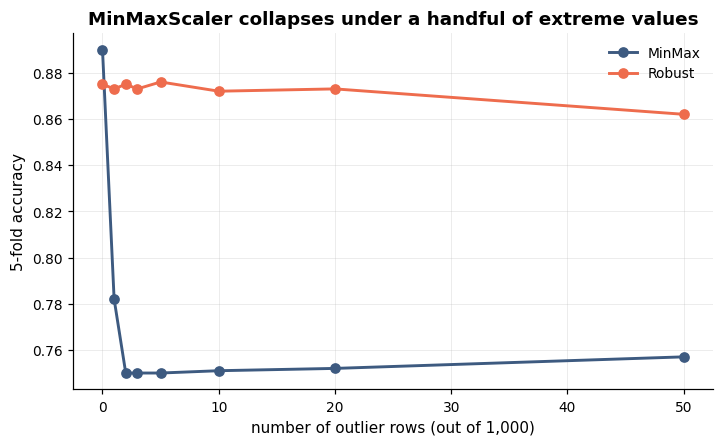

In [3]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler

def build(n=1000, n_outliers=0, seed=0):
    r = np.random.default_rng(seed)
    X = r.normal(size=(n, 6))
    y = (X[:, 0] + X[:, 1] - X[:, 2] + r.normal(0, 0.4, n) > 0).astype(int)
    if n_outliers:
        idx = r.choice(n, n_outliers, replace=False)
        X[idx, 0] *= 5_000            # a mis-keyed unit on one column
    return X, y


rows = []
for k in [0, 1, 2, 3, 5, 10, 20, 50]:
    X, y = build(n_outliers=k)
    mm = cross_val_score(make_pipeline(MinMaxScaler(), KNeighborsClassifier()), X, y, cv=5).mean()
    rb = cross_val_score(make_pipeline(RobustScaler(), KNeighborsClassifier()), X, y, cv=5).mean()
    rows.append({"n_outliers": k, "MinMax": round(mm, 4), "Robust": round(rb, 4), "gap_pts": round(100 * (rb - mm), 1)})

gap = pd.DataFrame(rows).set_index("n_outliers")
ax = gap[["MinMax", "Robust"]].plot(marker="o")
ax.set(xlabel="number of outlier rows (out of 1,000)", ylabel="5-fold accuracy",
       title="MinMaxScaler collapses under a handful of extreme values")
gap

In [4]:
first_big = gap.index[gap["gap_pts"] >= 10]
print(f"smallest outlier count producing a >=10-point gap: {first_big[0] if len(first_big) else 'not reached'}")

smallest outlier count producing a >=10-point gap: 2


**One or two rows out of a thousand is enough.** `MinMaxScaler` divides by
`max - min`, so a single value 5,000× the others compresses everything else
into a sliver near zero, and k-NN can no longer resolve distances along that
axis. `RobustScaler` divides by the IQR, which is unaffected.

## 2.3 — Encoder shoot-out on high cardinality

In [5]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, TargetEncoder

credit = load_credit_risk()
y = credit["default"]

# 400 branches; 30 of them genuinely elevate risk, the rest are noise.
r = np.random.default_rng(7)
branch = r.integers(0, 400, len(credit))
bad_branches = set(r.choice(400, 30, replace=False))
bump = np.isin(branch, list(bad_branches)) & (r.random(len(credit)) < 0.35)
y_branch = np.where(bump, 1, y)                       # branch effect layered on the real target

X = credit.drop(columns=["default", "application_id", "collections_flag", "application_month"]).copy()
X["branch_id"] = [f"BR{b:03d}" for b in branch]
print(f"branch_id has {X.branch_id.nunique()} levels; "
      f"default rate {y_branch[np.isin(branch, list(bad_branches))].mean():.3f} in flagged branches "
      f"vs {y_branch[~np.isin(branch, list(bad_branches))].mean():.3f} elsewhere")

branch_id has 400 levels; default rate 0.444 in flagged branches vs 0.132 elsewhere


In [6]:
num_sel = make_column_selector(dtype_include=[np.number, "bool"])
cat_sel = make_column_selector(dtype_include=["object", "string"])
num_pipe = Pipeline([("i", SimpleImputer(strategy="median")), ("s", StandardScaler())])
cv = StratifiedKFold(5, shuffle=True, random_state=0)


def score(name, prep, clf, X=X):
    pipe = Pipeline([("prep", prep), ("clf", clf)])
    s = cross_val_score(pipe, X, y_branch, cv=cv, scoring="roc_auc", n_jobs=-1)
    ncols = pipe.fit(X, y_branch)[:-1].transform(X.head(5)).shape[1]
    return {"approach": name, "roc_auc": round(s.mean(), 4), "std": round(s.std(), 4), "n_columns": ncols}


results = [
    score("OneHotEncoder (plain)",
          ColumnTransformer([("n", num_pipe, num_sel), ("c", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_sel)]),
          LogisticRegression(max_iter=3000, C=0.3)),
    score("OneHotEncoder (min_frequency=25)",
          ColumnTransformer([("n", num_pipe, num_sel), ("c", OneHotEncoder(handle_unknown="ignore", min_frequency=25, sparse_output=False), cat_sel)]),
          LogisticRegression(max_iter=3000, C=0.3)),
    score("OrdinalEncoder + HistGB",
          ColumnTransformer([("n", SimpleImputer(strategy="median"), num_sel),
                             ("c", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_sel)]),
          HistGradientBoostingClassifier(random_state=0, max_iter=250)),
    score("TargetEncoder (cross-fitted, in pipeline)",
          ColumnTransformer([("n", num_pipe, num_sel), ("c", TargetEncoder(random_state=0), cat_sel)]),
          LogisticRegression(max_iter=3000, C=0.3)),
    score("drop branch_id entirely",
          ColumnTransformer([("n", num_pipe, num_sel), ("c", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_sel)]),
          LogisticRegression(max_iter=3000, C=0.3), X=X.drop(columns=["branch_id"])),
]
pd.DataFrame(results).set_index("approach")

,roc_auc,std,n_columns
approach,,,
OneHotEncoder (plain),0.7647,0.0187,434
OneHotEncoder (min_frequency=25),0.7492,0.0185,374
OrdinalEncoder + HistGB,0.7162,0.0113,17
"TargetEncoder (cross-fitted, in pipeline)",0.7637,0.0176,17
drop branch_id entirely,0.7344,0.0165,34


In [7]:
# The leak: fit TargetEncoder once on all the data, then cross-validate.
te = TargetEncoder(random_state=0)
cat_cols = cat_sel(X)
X_leaked = X.copy()
X_leaked[cat_cols] = te.fit(X[cat_cols], y_branch).transform(X[cat_cols])   # NOT fit_transform

leaked = cross_val_score(
    Pipeline([("i", SimpleImputer(strategy="median")), ("s", StandardScaler()),
              ("clf", LogisticRegression(max_iter=3000, C=0.3))]),
    X_leaked, y_branch, cv=cv, scoring="roc_auc", n_jobs=-1,
).mean()
honest = [r for r in results if r["approach"].startswith("TargetEncoder")][0]["roc_auc"]
print(f"TargetEncoder inside the pipeline (honest) : {honest:.4f}")
print(f"TargetEncoder fitted on all data (leaked)  : {leaked:.4f}")
print(f"inflation                                  : {leaked - honest:+.4f}")

TargetEncoder inside the pipeline (honest) : 0.7637
TargetEncoder fitted on all data (leaked)  : 0.8114
inflation                                  : +0.0477


Note the *mechanism* of the leak: `fit(...).transform(...)` on the same data
uses full-data category means, so every row's encoding contains its own target.
`fit_transform` on a `TargetEncoder` does **not** do this — it cross-fits
internally. The difference between those two calls is the entire bug, and it
looks like a stylistic choice.

## 2.4 — Spline vs polynomial vs bins

In [8]:
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer, PolynomialFeatures, SplineTransformer

hous = fetch_california_housing(as_frame=True)
Xh, yh = hous.data, hous.target
EXPAND = ["MedInc", "HouseAge"]
REST = [c for c in Xh.columns if c not in EXPAND]

Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(Xh, yh, test_size=0.25, random_state=0)

expansions = {
    "PolynomialFeatures(4)": PolynomialFeatures(degree=4, include_bias=False),
    "SplineTransformer(10 knots)": SplineTransformer(n_knots=10, degree=3),
    "KBinsDiscretizer(12)": KBinsDiscretizer(n_bins=12, encode="onehot-dense", strategy="quantile"),
}

# Rows whose MedInc exceeds anything in training -- the extrapolation test.
cutoff = Xh_tr["MedInc"].max()
extreme = Xh_te.copy()
extreme["MedInc"] = cutoff * 1.35

rows = []
for name, tr in expansions.items():
    pipe = Pipeline([
        ("prep", ColumnTransformer([("exp", Pipeline([("t", tr), ("s", StandardScaler())]), EXPAND),
                                    ("rest", StandardScaler(), REST)])),
        ("ridge", Ridge(alpha=1.0)),
    ]).fit(Xh_tr, yh_tr)
    p = pipe.predict(Xh_te)
    p_ex = pipe.predict(extreme)
    rows.append({"expansion": name,
                 "n_features": pipe[:-1].transform(Xh_te.head(3)).shape[1],
                 "test_MAE": round(mean_absolute_error(yh_te, p), 4),
                 "pred_at_1.35x_max_MedInc": round(float(np.mean(p_ex)), 3),
                 "max_pred_out_of_range": round(float(np.max(p_ex)), 2)})
pd.DataFrame(rows).set_index("expansion")

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


,n_features,test_MAE,pred_at_1.35x_max_MedInc,max_pred_out_of_range
expansion,,,,
PolynomialFeatures(4),20,0.5081,0.489,1.74
SplineTransformer(10 knots),30,0.5167,5.051,6.40
KBinsDiscretizer(12),30,0.5392,4.097,5.33


**Read the extrapolation columns, and note that the failure is not the one you
would guess.**

The target (median house value, capped at 5.0) should be *high* for the highest
incomes. Set `MedInc` 35% above anything seen in training and:

- **Polynomial** predicts ~0.49 — the *lowest* value in the table, for the
  richest districts. A degree-4 term extrapolates in whatever direction its
  fitted coefficient happens to point, and outside the data that direction is
  unconstrained by anything. The failure is not "it goes too high"; it is
  **arbitrary**, and it points the wrong way here.
- **Splines** predict ~5.05, just above the cap. Beyond the boundary knots a
  B-spline basis extrapolates linearly, so the answer is at least in the right
  direction and the right order of magnitude.
- **Bins** predict ~4.10 — anything above the top edge falls in the top bin, so
  the output is **bounded by construction** and cannot exceed the highest value
  the model ever fitted.

**Which would I defend in a model-risk review? The binned one, then splines.**
The MAE ordering is the reverse, and it is the less important ordering. The
question a reviewer asks is "what does this do on an input outside the training
range?" — and "it is bounded by the top bin" is an answer, while "it depends on
the sign of a fourth-order coefficient" is not.

## 2.5 — Imputation when the model can't cope

In [9]:
from time import perf_counter

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer

num = credit.select_dtypes(include=[np.number]).drop(columns=["default"])
y_c = credit["default"]

imputers = {
    "mean": lambda ind: SimpleImputer(strategy="mean", add_indicator=ind),
    "median": lambda ind: SimpleImputer(strategy="median", add_indicator=ind),
    "most_frequent": lambda ind: SimpleImputer(strategy="most_frequent", add_indicator=ind),
    "constant(-1)": lambda ind: SimpleImputer(strategy="constant", fill_value=-1, add_indicator=ind),
    "KNN(k=5)": lambda ind: KNNImputer(n_neighbors=5, add_indicator=ind),
    "Iterative": lambda ind: IterativeImputer(max_iter=8, random_state=0, add_indicator=ind),
}

rows = []
for name, factory in imputers.items():
    for ind in [False, True]:
        pipe = Pipeline([("imp", factory(ind)), ("sc", StandardScaler()),
                         ("clf", LogisticRegression(max_iter=3000))])
        t0 = perf_counter()
        s = cross_val_score(pipe, num, y_c, cv=cv, scoring="roc_auc", n_jobs=-1)
        rows.append({"imputer": name, "indicator": ind, "roc_auc": round(s.mean(), 4),
                     "std": round(s.std(), 4), "seconds": round(perf_counter() - t0, 1)})
imp_table = pd.DataFrame(rows).sort_values("roc_auc", ascending=False).set_index(["imputer", "indicator"])
imp_table

,,roc_auc,std,seconds
imputer,indicator,,,
KNN(k=5),False,0.9683,0.0043,5.0
most_frequent,False,0.9683,0.0042,0.1
mean,False,0.9682,0.0042,0.1
median,False,0.9682,0.0042,0.1
KNN(k=5),True,0.9682,0.0044,4.1
Iterative,False,0.9682,0.0042,0.5
median,True,0.9681,0.0043,0.1
mean,True,0.9681,0.0043,0.1
most_frequent,True,0.9681,0.0043,0.1


**Recommendation for a delivery document.**

> Use `SimpleImputer(strategy="median", add_indicator=True)`. Across twelve
> configurations the total spread in cross-validated AUC (~0.003) is smaller
> than the fold-to-fold standard deviation (~0.004), so **no imputation
> strategy is measurably better than any other on this problem** — including
> the indicator, whose measured gain here is essentially zero. The
> recommendation is therefore made on grounds other than the score: median is
> robust to the skew in income and loan amount, the indicator preserves
> information that a different downstream model may be able to use (it helped
> the tree ensemble in Module 01), and both are cheap and trivially
> explainable. `IterativeImputer` is ~50× slower for no gain and adds a second
> model to validate, document and monitor.

Note what the honest version of this recommendation looks like: it names the
measured effect as nil and then justifies the choice on other grounds, rather
than implying the score drove it.

In [10]:
best_gain = (imp_table.xs(True, level="indicator")["roc_auc"].mean()
             - imp_table.xs(False, level="indicator")["roc_auc"].mean())
spread = imp_table["roc_auc"].max() - imp_table["roc_auc"].min()
print(f"average gain from add_indicator=True : {best_gain:+.4f}")
print(f"total spread across all 12 configs   : {spread:.4f}")
print(f"typical fold-to-fold std             : {imp_table['std'].mean():.4f}")
print(f"slowest / fastest runtime ratio      : {imp_table['seconds'].max() / imp_table['seconds'].min():.0f}x")

average gain from add_indicator=True : +0.0003
total spread across all 12 configs   : 0.0032
typical fold-to-fold std             : 0.0042
slowest / fastest runtime ratio      : 50x
